In [1]:
# 导入必要的库
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from IPython.display import display, Markdown

# 添加 tools 目录到 sys.path (如果在其他目录运行)
tools_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
if str(tools_dir) not in sys.path:
    sys.path.insert(0, str(tools_dir))



# 设置 seaborn 样式和颜色
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 中文字体支持
plt.rcParams['axes.unicode_minus'] = False  # 负号显示

In [2]:
# 可视化文件的路径
CSV_PATH = "/Users/ethan/Documents/quality_report_20260118.csv"

df_raw = pd.read_csv(CSV_PATH)

In [3]:
df_raw.shape, df_raw.head()

((87, 58),
    task_id condition  annotator_id  active_time       iou  iou_manual  \
 0      459      semi             2      188.282  1.000000         1.0   
 1      461      semi             2        7.509  1.000000         1.0   
 2      462      semi             2     2121.889  0.886244         NaN   
 3      463      semi             2       80.294  1.000000         1.0   
 4      464      semi             2      320.776  1.000000         1.0   
 
    iou_corner   rmse_px  layout_2d_iou  layout_3d_iou  ...  has_manual_poly  \
 0    1.000000  0.000000            NaN            NaN  ...             True   
 1    1.000000  0.000000            NaN            NaN  ...             True   
 2    0.886244  9.109372            NaN            NaN  ...            False   
 3    1.000000  0.000000            NaN            NaN  ...             True   
 4    1.000000  0.000000            NaN            NaN  ...             True   
 
    task_scope_n_total  task_scope_n_in_scope task_scope_n_oo

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_id                  87 non-null     int64  
 1   condition                87 non-null     object 
 2   annotator_id             87 non-null     int64  
 3   active_time              87 non-null     float64
 4   iou                      87 non-null     float64
 5   iou_manual               71 non-null     float64
 6   iou_corner               87 non-null     float64
 7   rmse_px                  87 non-null     float64
 8   layout_2d_iou            47 non-null     float64
 9   layout_3d_iou            47 non-null     float64
 10  layout_depth_rmse        47 non-null     float64
 11  layout_delta1            47 non-null     float64
 12  layout_used              87 non-null     bool   
 13  layout_gate_reason       40 non-null     object 
 14  pointwise_rmse_px        66 

# 数据清洗（可审计口径）

目标：统一字段语义，并把过滤条件固化为掩码列，供后续所有图/表直接复用。

- **透明报告集**：`df_transparent`（不做过滤；只做标准化与缺失/分布统计）
- **主分析集**：`df_main`（`data_valid_for_main=True`；默认要求 In-scope 且 `layout_used=True`）
- **可靠性集**：`df_rel`（`data_valid_for_reliability=True`；多标注且 LOO 指标可用，**2026-01-19更新**：增加 `reliability_used=True` 条件与上游BUG-C01修复一致）

In [5]:
# 主分析集是否强制要求 layout_used=True（与 tools/save_quality_figures.py 的默认口径保持一致）
REQUIRE_LAYOUT_USED_FOR_MAIN = True

def _clean_str_col(df: pd.DataFrame, col: str) -> None:
    """标准化字符串列：去空格、小写、空串/伪空值 → NA。"""
    if col not in df.columns:
        return
    s = df[col].astype("string")
    s = s.str.strip().str.lower()
    s = s.replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})
    df[col] = s

def _to_bool_or_na(x):
    """稳健的三态布尔：True / False / NA（未知/缺失保持 NA）。"""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    s = str(x).strip().lower()
    if s in {"true", "1", "yes", "y", "t"}:
        return True
    if s in {"false", "0", "no", "n", "f"}:
        return False
    return pd.NA

def clean_quality_df(df: pd.DataFrame, require_layout_used_for_main: bool = True, verbose: bool = True) -> pd.DataFrame:
    """把 analyze_quality.py 导出的长表清洗成论文可复用的统一口径。
    输出：清洗后的字段 + 三个集合掩码 + 异常标记（不直接删样本）。
    """
    df = df.copy()  # 避免就地修改，保证可追溯

    # 1) 关键标识列统一为字符串（避免读成 float 造成聚合/合并问题）
    for col in ["task_id", "annotator_id"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # 2) 关键字符串列标准化
    for col in [
        "scope", "difficulty", "model_issue",
        "layout_gate_reason", "pointwise_gate_reason", "quality", "condition",
    ]:
        _clean_str_col(df, col)

    # 3) scope 口径（按你当前导出：英文 v2 token）
    # 观察到 scope 值形如：normal / oos_split_level / oos_insufficient（且不含 ';'）。
    # 因此这里保持"原先正确的口径"：oos 通过前缀判断；normal 通过等值判断。
    df["scope_clean"] = df["scope"]
    df["scope_missing"] = df["scope_clean"].isna()

    def scope_is_oos(s):
        if pd.isna(s):
            return False
        ss = str(s).strip().lower()
        return ss.startswith("oos") or ss.startswith("out-of-scope") or ss.startswith("out of scope")

    def scope_is_normal(s):
        if pd.isna(s):
            return False
        ss = str(s).strip().lower()
        # 当前 v2 导出用 normal 表示 in-scope；兼容少量历史/英文变体
        return (ss == "normal") or ss.startswith("in-scope") or ("camera room" in ss)

    df["is_oos_clean"] = df["scope_clean"].apply(scope_is_oos)
    df["is_normal_clean"] = df["scope_clean"].apply(scope_is_normal)

    # 4) condition：缺失→unknown；并定义 model_issue 的适用范围（仅 semi）
    if "condition" in df.columns:
        df["condition_clean"] = df["condition"].fillna("unknown")
    else:
        df["condition_clean"] = "unknown"

    df["model_issue_applicable"] = df["condition_clean"].eq("semi")
    df["difficulty_reported"] = df["difficulty"].fillna("").str.strip().ne("")
    df["model_issue_reported"] = df["model_issue"].fillna("").str.strip().ne("")

    # 5) bool 列统一为三态：True/False/NA（缺失不硬填 False）
    for col in ["layout_used", "pointwise_rmse_used", "pairing_warning", "pred_odd_points", "ann_odd_points", "reliability_used"]:
        if col in df.columns:
            df[f"{col}_clean"] = df[col].apply(_to_bool_or_na)

    # 6) gate_reason 仅在 used=False 且 reason 为空时补 unknown，便于统计分布
    if "layout_used_clean" in df.columns and "layout_gate_reason" in df.columns:
        mask = (df["layout_used_clean"].eq(False) & df["layout_gate_reason"].fillna("").str.strip().eq(""))
        df.loc[mask, "layout_gate_reason"] = "unknown_gate_reason"

    if "pointwise_rmse_used_clean" in df.columns and "pointwise_gate_reason" in df.columns:
        mask = (df["pointwise_rmse_used_clean"].eq(False) & df["pointwise_gate_reason"].fillna("").str.strip().eq(""))
        df.loc[mask, "pointwise_gate_reason"] = "unknown_gate_reason"

    # 7) 三个集合掩码：后续图/表只引用这些掩码，避免口径漂移
    df["data_valid_inscope"] = (df["scope_missing"].eq(False) & df["is_oos_clean"].eq(False))

    if require_layout_used_for_main and "layout_used_clean" in df.columns:
        df["data_valid_for_main"] = df["data_valid_inscope"] & df["layout_used_clean"].eq(True)
    else:
        df["data_valid_for_main"] = df["data_valid_inscope"]

    # 可靠性/一致性：多标注 + LOO 指标可用；并显式排除 mixed-scope / unknown-scope tasks（若脚本提供 task 级字段）
    # 修改1: 增加 reliability_used 条件，与上游BUG-C01修复保持一致
    if all(c in df.columns for c in ["consensus_uid_loo", "iou_to_consensus_loo"]):
        rel_mask = df["data_valid_inscope"] & df["consensus_uid_loo"].notna() & df["iou_to_consensus_loo"].notna()
        if "reliability_used_clean" in df.columns:
            rel_mask = rel_mask & df["reliability_used_clean"].eq(True)
        if "task_scope_n_total" in df.columns:
            rel_mask = rel_mask & df["task_scope_n_total"].fillna(0).astype(float).ge(2)
        if "task_scope_is_mixed" in df.columns:
            rel_mask = rel_mask & df["task_scope_is_mixed"].eq(False)
        if "task_scope_has_unknown" in df.columns:
            rel_mask = rel_mask & df["task_scope_has_unknown"].eq(False)
        df["data_valid_for_reliability"] = rel_mask
    else:
        df["data_valid_for_reliability"] = False

    # 8) 主分析剔除原因（单值字段，便于汇总/审计）
    reasons = np.select(
        [
            df["scope_missing"].eq(True),
            df["is_oos_clean"].eq(True),
            require_layout_used_for_main & (df.get("layout_used_clean", pd.Series([pd.NA] * len(df))).ne(True)),
        ],
        ["scope_missing", "oos", "layout_gate_or_missing"],
        default="ok",
    )
    df["main_exclude_reason"] = reasons

    # 9) 一致性检查：CSV 导出的 is_oos vs 基于 scope_clean 前缀派生的 is_oos_clean
    # 预期：在 v2 英文导出里应一致；不一致通常表示导出/解析异常或被手工改写。
    if "is_oos" in df.columns:
        df["is_oos_raw_bool"] = df["is_oos"].apply(_to_bool_or_na)
        df["flag_inconsistent_is_oos"] = False
        mask = df["is_oos_raw_bool"].notna()
        if mask.any():
            a = df.loc[mask, "is_oos_raw_bool"].astype(bool).to_numpy()
            b = df.loc[mask, "is_oos_clean"].astype(bool).to_numpy()
            df.loc[mask, "flag_inconsistent_is_oos"] = (a != b)
    else:
        df["flag_inconsistent_is_oos"] = False

    # 10) 指标/时间等异常标记（不删样本；用于透明报告与反例表）
    if "active_time" in df.columns:
        at = pd.to_numeric(df["active_time"], errors="coerce")
        df["flag_active_time_missing"] = at.isna()
        df["flag_active_time_zero"] = at.fillna(0).eq(0)
        if at.notna().any():
            p99 = float(np.nanpercentile(at.to_numpy(dtype=float), 99))
            df["flag_active_time_p99"] = at.gt(p99)
        else:
            df["flag_active_time_p99"] = False

    for col in ["iou", "iou_corner", "iou_manual", "iou_to_consensus_loo", "iou_to_others_median"]:
        if col in df.columns:
            v = pd.to_numeric(df[col], errors="coerce")
            df[f"flag_{col}_missing"] = v.isna()
            df[f"flag_{col}_out_of_01"] = v.lt(0) | v.gt(1)

    if "boundary_rmse_px" in df.columns:
        v = pd.to_numeric(df["boundary_rmse_px"], errors="coerce")
        df["flag_boundary_rmse_missing"] = v.isna()
        if v.notna().any():
            p99 = float(np.nanpercentile(v.to_numpy(dtype=float), 99))
            df["flag_boundary_rmse_p99"] = v.gt(p99)
        else:
            df["flag_boundary_rmse_p99"] = False

    # 修改2: Sanity check - reliability_used==False 时不应有 LOO 共识值
    if all(c in df.columns for c in ["reliability_used_clean", "iou_to_consensus_loo"]):
        invalid = df[
            (df["reliability_used_clean"] == False) 
            & df["iou_to_consensus_loo"].notna()
        ]
        if len(invalid) > 0 and verbose:
            print("=" * 70)
            print(f"⚠️  SANITY CHECK WARNING: {len(invalid)} rows have reliability_used=False but iou_to_consensus_loo is not None")
            print("This indicates upstream BUG-C01 (已在 2026-01-19 修复，旧数据可能存在)")
            print("Sample rows:")
            display(invalid[['task_id', 'annotator_id', 'reliability_used', 'reliability_gate_reason', 'iou_to_consensus_loo']].head(5))
            print("=" * 70)

    if verbose:
        print("=" * 70)
        print("清洗摘要（可审计口径）")
        print("=" * 70)
        print(f"总行数: {len(df)}")
        print(f"scope 缺失: {df['scope_missing'].sum()} ({df['scope_missing'].mean():.1%})")
        if "scope_clean" in df.columns:
            print("scope 分布（含缺失）:")
            print(df["scope_clean"].fillna("(missing)").value_counts())
        valid_scope = df[~df["scope_missing"]]
        if len(valid_scope) > 0:
            oos_rate = valid_scope["is_oos_clean"].mean()
            print(f"OOS 比例（scope非空）: {oos_rate:.1%}")
        print(f"difficulty 填写率（总体）: {df['difficulty_reported'].mean():.1%}")
        if df["model_issue_applicable"].any():
            mi_rate = df.loc[df["model_issue_applicable"], "model_issue_reported"].mean()
            print(f"model_issue 填写率（仅semi）: {mi_rate:.1%}")
        print(f"主分析集样本数: {df['data_valid_for_main'].sum()}")
        print("主分析剔除原因分布:")
        print(pd.Series(df["main_exclude_reason"]).value_counts())
        
        # 额外统计：reliability_used 与 data_valid_for_reliability 的差异
        if "reliability_used_clean" in df.columns:
            n_reliability_used = df["reliability_used_clean"].eq(True).sum()
            n_reliability_valid = df["data_valid_for_reliability"].sum()
            print(f"\nreliability_used=True: {n_reliability_used}")
            print(f"data_valid_for_reliability=True: {n_reliability_valid}")
            diff = n_reliability_used - n_reliability_valid
            if diff != 0:
                print(f"Difference: {diff} (任务级过滤导致的差异)")
        
        n_incon = int(df["flag_inconsistent_is_oos"].sum())
        if n_incon > 0:
            print(f"[WARN] is_oos 与 scope 派生口径不一致: {n_incon} 行")
        # 条件字段审计（避免 manual/semi 混淆）
        if "condition_clean" in df.columns:
            bad = ~df["condition_clean"].isin(["manual", "semi", "unknown"])
            if bad.any():
                print("[WARN] condition_clean 出现非预期取值:")
                print(df.loc[bad, "condition_clean"].value_counts())
        print("=" * 70)

    return df

df_clean = clean_quality_df(df_raw, require_layout_used_for_main=REQUIRE_LAYOUT_USED_FOR_MAIN, verbose=True)

# 三个数据视图：透明 / 主分析 / 可靠性
df_transparent = df_clean
df_main = df_clean[df_clean["data_valid_for_main"]].copy()
df_rel = df_clean[df_clean["data_valid_for_reliability"]].copy()

len(df_transparent), len(df_main), len(df_rel)

清洗摘要（可审计口径）
总行数: 87
scope 缺失: 14 (16.1%)
scope 分布（含缺失）:
scope_clean
normal              61
(missing)           14
oos_split_level     11
oos_insufficient     1
Name: count, dtype: Int64
OOS 比例（scope非空）: 16.4%
difficulty 填写率（总体）: 27.6%
model_issue 填写率（仅semi）: 28.7%
主分析集样本数: 47
主分析剔除原因分布:
main_exclude_reason
ok                        47
scope_missing             14
layout_gate_or_missing    14
oos                       12
Name: count, dtype: int64


(87, 47, 27)

# 后续图表（每图/表一格）

从这一节开始：**每个图/表用一个 Markdown 单元格说明**，紧跟一个空的 Python 单元格，方便你在说明下面直接写对应代码。

统一口径（来自清洗结果，**2026-01-19更新**）：
- **透明报告集**：`df_transparent`（= `df_clean`），不做过滤，用于缺失率 / scope / 门控统计等
- **主分析集（严格）**：`df_main`（`data_valid_for_main=True`），用于主指标与"正式"结果
- **可靠性集**：`df_rel`（`data_valid_for_reliability=True`），用于一致性/IAA（LOO 指标）
  - ⚠️ **重要变更**: 现在 `df_rel` 额外要求 `reliability_used=True`，确保只包含实际参与共识计算的行
  - 这修复了BUG-C01：`reliability_used` 字段与实际共识计算逻辑的不一致

对齐项目说明：tools/README.md 中 batch 脚本 `save_quality_figures.py` 的标准图集（scope 分布、layout gate reason、metric 分布、metric vs time、按标注者、热力图、mixed-scope）也会在下面给出对应的图项，你可以选择性复现或替换成论文版图。

## 表 1：字段缺失率与 active_time 覆盖率（透明报告集）

**数据集**：`df_transparent`（无过滤）  
**核心列**：
- `scope_clean`/`scope_missing`
- `difficulty`, `model_issue`（以及 *_reported 统计）
- `active_time`（含 active_time==0 比例）
- gate 信息：`layout_used_clean`, `pointwise_rmse_used_clean`, `layout_gate_reason`, `pointwise_gate_reason`
- 指标列：layout / iou / rmse 等（按你论文选用）

**目的**：论文“数据卫生/透明报告”的主表：让读者明白哪些字段缺失、缺失是否系统性、耗时记录是否可靠。

**你要写的代码**：
1. 逐列缺失率：`df_transparent[col].isna().mean()`
2. 对 `active_time` 额外统计：==0 比例、p50/p95/p99
3. 对 gate_reason：在 used=False 时 reason 为空/unknown 的比例
4. 输出表格（DataFrame + display）

In [6]:
# TODO（表1）：字段缺失率与 active_time 覆盖率
# df_transparent 上逐列统计 missing_rate、active_time==0、以及 gate_reason 的空值比例


## 图 A：active_time 分布与 In-scope 对比（透明报告集，数据卫生补充）

（这张图不是 tools/save_quality_figures.py 的标准输出，但对论文的数据卫生段落很有用。）

**数据集**：`df_transparent`  
**核心列**：`active_time`, `data_valid_inscope`（以及可选的 `condition_clean`）

**目的**：
- 验证耗时记录是否“像真的”（是否大量为 0 / 是否极端长尾）
- 对比 In-scope vs OOS/缺失样本的耗时差异，解释后续质量指标的偏差来源

**你要写的代码**：
1. 分布图：active_time 的 hist/KDE（必要时 log-x）
2. 对比：按 data_valid_inscope 分层/分面
3. 标注：active_time==0 比例、p95/p99、长尾样本数量

In [7]:
# TODO（图A）：active_time 分布与 In-scope 对比（透明报告集）
# 建议：hist/KDE + 标注 active_time==0 比例与 p99；对比 data_valid_inscope=True/False


## 图 1：Scope / OOS 比例与子类分布（透明报告集）

对齐 tools/README.md 的标准输出 `scope_distribution.png` / `01_rows_by_scope.png`。你也可以在论文版图里用更细的 `scope_clean` 子类（如 oos_geometry 等）。

**数据集**：`df_transparent`  
**核心列**：`scope_clean`, `scope_missing`, `is_oos_clean`, （可选）`condition_clean`

**目的**：作为论文/报告的“数据口径入口图”：交代 OOS 比例、scope 子类组成，以及 scope 缺失是否存在。

**你要写的代码**：
1. scope_plot = scope_clean.fillna('(missing)')
2. countplot/barplot（可按 condition_clean 分色）
3. 同时输出一段文本统计：OOS 比例、missing 比例

In [8]:
# TODO（图1）：Scope / OOS 比例与子类分布
# df_transparent 上统计 scope_clean（含缺失），必要时按 condition_clean 分层


## 图 2：layout 门控失败原因分布（透明报告集）

对齐 tools/README.md 的标准输出 `layout_gate_reasons.png` / `02_layout_gate_reason.png`。

**数据集**：`df_transparent`（重点看 gate 行为）  
**筛选**：`layout_used_clean == False`  
**核心列**：`layout_used_clean`, `layout_gate_reason`（缺失已补为 `unknown_gate_reason`）

**目的**：给出“为什么样本进不了主分析”的结构性解释，避免审稿人误解为“挑结果/选择性汇报”。

**你要写的代码**：
1. 统计 layout_gate_reason 的频数并排序
2. bar/count plot
3. （可选）按 `condition_clean` 分层对比

In [9]:
# TODO（图2）：layout 门控失败原因分布
# df_transparent 中 layout_used_clean==False 的样本，统计 layout_gate_reason


### 图 3：关键指标分布（主分析口径）

**目的**
- 展示主分析集 (`df_main`) 的核心指标分布形态（例如 IoU、Boundary RMSE 等），用于描述总体质量和长尾。

**输入数据**
- 使用 `df_main`。
- 对每个指标单独做 `.notna()`：
  - 指标为 NA 代表“不可计算/缺失”，不等价于 0；不能直接当作低质量样本。
  - 典型原因：预测缺失、几何退化、被 gate 掉的计算路径（例如 layout 未使用）。

**建议呈现**
- 对称分布：直方图/核密度
- 长尾：对数坐标或分位数曲线
- 透明性：同时标注 `flag_{metric}_missing` 的比例（如果要在论文里解释缺失率）

```python
# TODO: 画分布图（此处先不实现绘图代码）
```


In [10]:
# TODO（图3）：指标分布（按 scope 分层）
# df_main（主结果）或 df_transparent（透明对比）；hist/violin/ECDF


## 图 4：指标 vs 标注时间（log-x）

对齐 tools/README.md 的标准输出 `iou_vs_time.png`。

**数据集**：`df_main`（论文主结果），也可用 `df_transparent` 做透明对比  
**核心列**：
- `active_time`
- 主指标列（`iou`/`iou_corner`/`iou_manual`）
- （可选）`scope_clean`/`condition_clean`/`annotator_id`

**目的**：回应论文常见质疑：耗时是否与质量相关？是否存在“极短耗时但高质量/低质量”的异常。

**你要写的代码**：
1. scatter：x=active_time, y=metric（x 轴 log）
2. 分层：hue=scope 或 condition；style=annotator_id（可选）
3. 给出相关系数（Spearman 更稳健）

In [11]:
# TODO（图4）：指标 vs 标注时间（log-x）
# df_main 或 df_transparent：散点图 x=active_time, y=metric；按 scope/condition/annotator 分组


## 图 5：标注者间指标分布（按标注者）

对齐 tools/README.md 的标准输出 `iou_by_annotator.png`。

**数据集**：建议用 `df_main`（主指标一致），也可对比 `df_transparent`  
**核心列**：`annotator_id` + 你选定的主指标列（`iou`/`iou_corner`/`iou_manual`）

**目的**：识别标注者间系统性差异（偏松/偏严），并作为一致性分析的前置证据（也可解释可靠性结果）。

**你要写的代码**：
1. boxplot + stripplot
2. （可选）按 `condition_clean` 分面/分色
3. 输出标注者级 summary（median/IQR）

In [12]:
# TODO（图5）：标注者间指标箱线图
# df_main 或 df_transparent：按 annotator_id 对比主指标（如 iou/iou_corner）


## 图 6：标注者耗时分布（按标注者，log-y）

对齐 tools/README.md 的标准输出 `time_by_annotator.png`。

**数据集**：`df_transparent`（看全量耗时），也可用 `df_main` 看主结果耗时  
**核心列**：`annotator_id`, `active_time`

**目的**：验证标注工作量是否均衡、是否存在系统性“快但低质/慢但高质”的标注者差异。

**你要写的代码**：
1. x=annotator_id, y=active_time 的 boxplot + stripplot
2. y 轴 log scale
3. （可选）在同图上叠加主指标（需要双轴或分面）

In [13]:
# TODO（图6）：标注者耗时箱线图（log-y）
# df_transparent 或 df_main：按 annotator_id 对比 active_time 分布


## 图 7：任务×标注者热力图（分歧发现，主分析/透明均可）

对齐 tools/README.md 的标准输出 `task_annotator_heatmap.png`。

**数据集**：建议用 `df_main`（主指标一致），也可对比 `df_transparent`  
**核心列**：
- `task_id`, `annotator_id`
- `iou`（或你论文指定的主指标列）

**目的**：用可视化直接定位“哪个任务分歧最大 / 哪个标注者偏离系统性更明显”，用于标注指南迭代与审稿人质疑回应。

**你要写的代码**：
1. pivot：index=task_id, columns=annotator_id, values=metric
2. 选择 top-N 个最有信息的任务（如方差最大）
3. heatmap 绘制并标注缺失（NA）

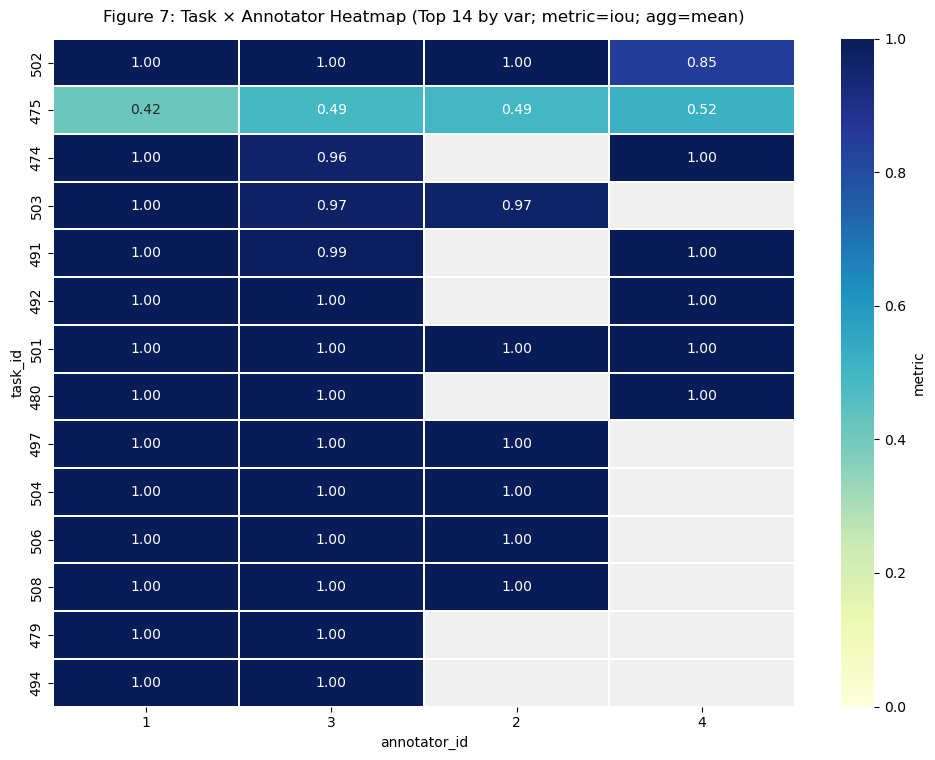

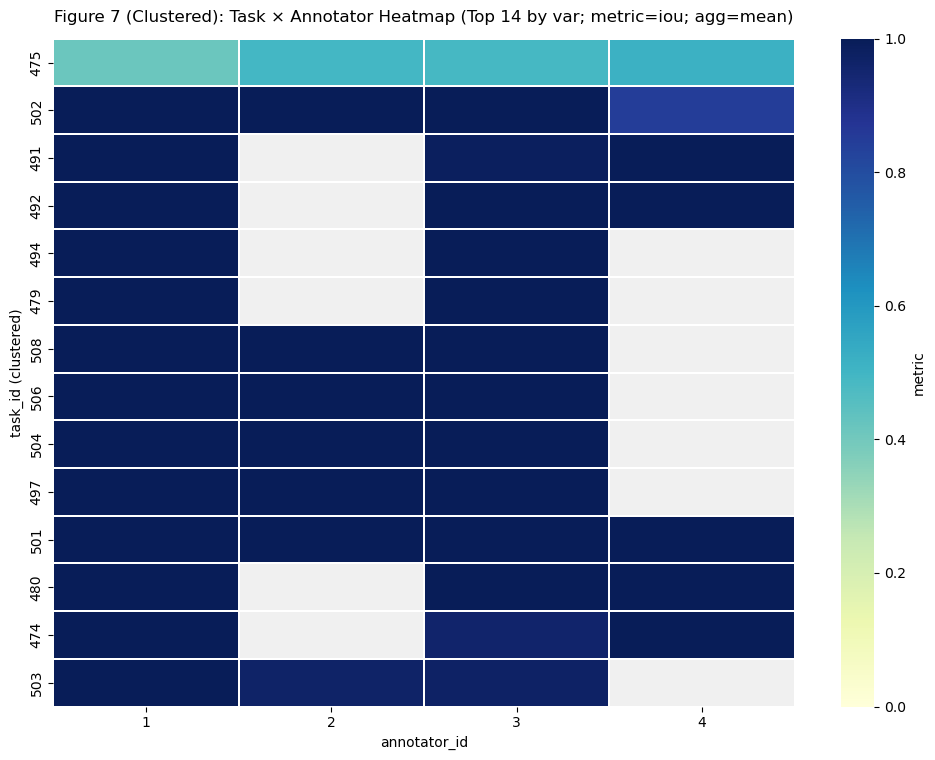

Saved:
- output/task_annotator_heatmap.png
- output/task_annotator_heatmap_clustered.png


,score,ann_cnt
task_id,,
502,0.005979,4
475,0.001896,4
474,0.000523,3
503,0.000303,3
491,0.000062,3
492,0.000002,3
501,0.000000,4
480,0.000000,3
497,0.000000,3


In [21]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
import warnings
warnings.filterwarnings("ignore")

class TaskAnnotatorHeatmapVisualizer:
    """
    Figure 7: Task × Annotator Heatmap (Divergence Detection)
    - Input: Long-form df (must contain task_id, annotator_id, metric_col)
    - Output: Heatmap PNG (optional clustered version)
    """
    def __init__(self, figsize=(12, 8), output_dir="output"):
        self.figsize = figsize
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.setup_style()

    def setup_style(self):
        plt.style.use("default")
        plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
        plt.rcParams["axes.unicode_minus"] = False

    # ---------- 1) Data Preparation: Long table -> task×annotator matrix ----------
    def build_matrix(self, df: pd.DataFrame, metric_col="iou", agg="mean", min_annotators=2):
        need = {"task_id", "annotator_id", metric_col}
        missing = need - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns: {missing}")

        tmp = df[["task_id", "annotator_id", metric_col]].copy()
        tmp["task_id"] = tmp["task_id"].astype(str)
        tmp["annotator_id"] = tmp["annotator_id"].astype(str)
        tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")

        mat = tmp.pivot_table(
            index="task_id",
            columns="annotator_id",
            values=metric_col,
            aggfunc=("median" if agg == "median" else "mean")
        )

        # Filter: keep only tasks with at least min_annotators
        ann_cnt = mat.notna().sum(axis=1)
        mat = mat.loc[ann_cnt >= min_annotators]
        return mat

    # ---------- 2) Divergence Analysis: Select Top-N tasks ----------
    def select_top_divergent_tasks(self, mat: pd.DataFrame, top_n=20, rank_by="var"):
        if mat.empty:
            raise ValueError("Matrix is empty (filter conditions may be too strict or data is missing).")

        if rank_by == "range":
            score = mat.max(axis=1, skipna=True) - mat.min(axis=1, skipna=True)
        else:
            score = mat.var(axis=1, skipna=True)

        ann_cnt = mat.notna().sum(axis=1)

        score_df = (
            pd.DataFrame({"score": score, "ann_cnt": ann_cnt})
              .sort_values(["score", "ann_cnt"], ascending=[False, False])
        )

        sel_tasks = score_df.head(top_n).index
        return mat.loc[sel_tasks], score_df

    # ---------- 3) Plotting: Seaborn Heatmap ----------
    def create_seaborn_heatmap(
        self,
        mat: pd.DataFrame,
        title="Figure 7: Task × Annotator Heatmap (Top Divergent Tasks)",
        filename="task_annotator_heatmap.png",
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        fix_01=True,
    ):
        # Sort columns by mean value for easier observation of annotator bias
        col_order = mat.mean(axis=0, skipna=True).sort_values(ascending=False).index
        mat = mat[col_order]

        plt.figure(figsize=(max(10, 0.8 * mat.shape[1]), max(6, 0.55 * mat.shape[0])))

        heatmap_kwargs = dict(
            data=mat,
            cmap=cmap,
            annot=annot,
            fmt=fmt,
            linewidths=0.3,
            linecolor="white",
            mask=mat.isna(),
            cbar_kws={"label": "metric"},
        )
        if fix_01:
            heatmap_kwargs.update(dict(vmin=0, vmax=1))

        ax = sns.heatmap(**heatmap_kwargs)
        ax.set_facecolor("#f0f0f0")

        ax.set_title(title, pad=12)
        ax.set_xlabel("annotator_id")
        ax.set_ylabel("task_id")

        plt.tight_layout()
        out_path = os.path.join(self.output_dir, filename)
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        return out_path

    # ---------- 4) Optional: Clustered Heatmap (Academic Version) ----------
    def create_clustered_heatmap(
        self,
        mat: pd.DataFrame,
        title="Figure 7 (Clustered): Task × Annotator Heatmap",
        filename="task_annotator_heatmap_clustered.png",
        cmap="YlGnBu",
        annot=False,
        fmt=".2f",
        fix_01=True,
    ):
        # Cluster rows (tasks): fill NA with row mean for distance calculation
        filled = mat.copy()
        row_mean = filled.mean(axis=1)
        filled = filled.T.fillna(row_mean).T

        # Distance: Euclidean (more stable than correlation for this case)
        dist = filled.to_numpy()
        linkage_matrix = linkage(dist, method="ward")
        order = leaves_list(linkage_matrix)

        mat_ord = mat.iloc[order, :]

        plt.figure(figsize=(max(10, 0.8 * mat_ord.shape[1]), max(6, 0.55 * mat_ord.shape[0])))

        heatmap_kwargs = dict(
            data=mat_ord,
            cmap=cmap,
            annot=annot,
            fmt=fmt,
            linewidths=0.3,
            linecolor="white",
            mask=mat_ord.isna(),
            cbar_kws={"label": "metric"},
        )
        if fix_01:
            heatmap_kwargs.update(dict(vmin=0, vmax=1))

        ax = sns.heatmap(**heatmap_kwargs)
        ax.set_facecolor("#f0f0f0")
        ax.set_title(title, pad=12)
        ax.set_xlabel("annotator_id")
        ax.set_ylabel("task_id (clustered)")

        plt.tight_layout()
        out_path = os.path.join(self.output_dir, filename)
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        return out_path

    # ---------- 5) One-click run Figure 7 ----------
    def run_fig7(
        self,
        df: pd.DataFrame,
        metric_col="iou",
        agg="mean",
        min_annotators=2,
        top_n=20,
        rank_by="var",
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
    ):
        mat = self.build_matrix(df, metric_col=metric_col, agg=agg, min_annotators=min_annotators)
        mat_sel, score_df = self.select_top_divergent_tasks(mat, top_n=top_n, rank_by=rank_by)

        title = f"Figure 7: Task × Annotator Heatmap (Top {len(mat_sel)} by {rank_by}; metric={metric_col}; agg={agg})"
        out1 = self.create_seaborn_heatmap(
            mat_sel,
            title=title,
            filename="task_annotator_heatmap.png",
            cmap=cmap,
            annot=annot,
            fmt=fmt,
            fix_01=(metric_col.lower().startswith("iou")),
        )

        # Also generate clustered version (optional)
        out2 = self.create_clustered_heatmap(
            mat_sel,
            title=title.replace("Figure 7:", "Figure 7 (Clustered):"),
            filename="task_annotator_heatmap_clustered.png",
            cmap=cmap,
            annot=False,  # Clustered version without annotations for cleaner look
            fmt=fmt,
            fix_01=(metric_col.lower().startswith("iou")),
        )

        print("Saved:")
        print("-", out1)
        print("-", out2)
        display(score_df.head(top_n))

        return mat_sel, score_df

# Run visualization
viz = TaskAnnotatorHeatmapVisualizer(figsize=(12, 8), output_dir="output")

mat_sel, score_df = viz.run_fig7(
    df=df_main,          # Main analysis dataset; can also use df_transparent
    metric_col="iou",
    agg="mean",
    min_annotators=2,
    top_n=20,
    rank_by="var",       # or "range"
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
)

## 图 8：Mixed-scope 任务可视化（透明报告集 / 任务级）

对齐 tools/README.md 的标准输出 `mixed_scope_tasks.png`。

**数据集**：`df_transparent`（但需要先按 `task_id` 聚合/统计）  
**核心列**：
- `task_id`
- `scope_clean`（或原始 `scope`）
- （可选）`task_scope_n_total` / `task_scope_is_mixed`（若 CSV 已包含）

**目的**：找出“同一任务不同标注者对 scope 判定不一致”的样本，这是质量控制/标注指南迭代的关键证据。

**你要写的代码**：
1. 任务级统计：每个 task 的 scope 唯一值数（nunique）
2. 筛选 nunique>1 的 task_id
3. 输出 task 列表（可附上每个 task 的 scope 投票分布）

In [15]:
# TODO（图8）：Mixed-scope 任务可视化
# 目标：找出同一 task 不同标注者 scope 不一致的任务，并做列表/小图展示


## 图 9：标注者一致性对比——个体 vs 共识 / 个体 vs 同行（可靠性集）

**数据集**：`df_rel`（多标注 + LOO 指标可用 + `reliability_used=True`）  
**核心列**：
- `iou_to_consensus_loo`：个体与 leave-one-out 共识的 IoU
- `iou_to_others_median`：个体与其他标注者的中位 IoU
- （可选）`condition_clean`, `task_scope_n_total`

**目的**：这是论文"标注可靠性"最关键的证据图之一：说明标注者对同一任务的收敛程度，以及共识稳定性。

**注意事项（2026-01-19更新）**：
- `df_rel` 现已包含 `reliability_used=True` 过滤，确保只展示实际参与共识计算的行
- 如需分层报告 n≥3 vs n=2 任务，可使用 `task_scope_n_total` 列
- n=2 任务的 LOO 退化为 pairwise，需在论文中clarify

**你要写的代码**：
1. 并列分布（box/violin）或散点对比（x=others_median, y=consensus_loo）
2. （可选）按 `condition_clean` 或 `task_scope_n_total` 分层
3. 输出关键统计：中位数、IQR、低分位数

In [16]:
# TODO（图9）：标注者一致性对比（可靠性集）
# df_rel 上对比 iou_to_consensus_loo vs iou_to_others_median（可按 condition_clean 分层）


## 图 10：标注者间协议指数分布（IAA，可靠性集）

**数据集**：`df_rel`（已包含 `reliability_used=True` 过滤）  
**核心列**：
- `iou_to_others_median`：与其他标注者的中位 IoU（IAA 代理指标）
- （可选）`task_id`, `annotator_id`, `task_scope_n_total`：用于聚合/分组

**目的**：给出 IAA 的整体分布与长尾，支撑论文对标注一致性与可靠性结论。

**注意事项（2026-01-19更新）**：
- 由于增加了 `reliability_used=True` 过滤，样本数可能比原始CSV少
- 可通过 `clean_quality_df()` 的 verbose 输出查看过滤前后差异
- 建议在论文方法部分说明：可靠性分析排除了 mixed-scope / unknown-scope / n<2 任务

**你要写的代码**：
1. 分布图（hist/KDE/violin）展示 `iou_to_others_median`
2. 标注异常低协议样本（如 IQR 下界）
3. （可选）按 `annotator_id` 输出 IAA 汇总表
4. （可选）分层报告 n≥3 vs n=2 任务的 IAA 差异

In [17]:
# TODO（图10）：标注者间协议指数分布（IAA，可靠性集）
# df_rel 上做分布图；必要时按 annotator_id / task_id 聚合


### 表 4：低质量/异常样本清单（审计用；不用于显著性结论）

**目的**
- 给出“可复现的反例清单”：哪些样本在主分析口径下表现差、或存在明显异常（例如耗时极高、指标越界、scope/字段不一致等）。

**输入数据**
- 使用 `df_main`（统一主分析口径：in-scope 且（可选）layout_used=True）。
- 反例表涉及到某一指标（例如 IoU / boundary_rmse_px）时，必须额外加 `.notna()` 过滤：
  - `IoU`/`iou_*` 为 NA 表示“不可计算/缺失”（例如缺少预测、几何退化），不是 0 分。

**建议列（每行一个 task×annotator）**
- `task_id, annotator_id, condition_clean`
- `scope_clean, scope_missing, is_oos_clean`
- `layout_used_clean, layout_gate_reason`
- `active_time`
- 指标：`iou`（或你论文里定义的主 IoU 字段）、`boundary_rmse_px`、`pointwise_rmse`（若存在）
- 可靠性相关（可选）：`iou_to_consensus_loo, iou_to_others_median`
- 异常标记：`flag_*` 与 `main_exclude_reason`

**排序建议（只在该指标可计算时排序）**
- “最差 IoU” → `iou` 升序（但先 `.notna()`）
- “最差边界” → `boundary_rmse_px` 降序（但先 `.notna()`）
- “高耗时低改动” → `active_time` 降序，且要求 `active_time` 与 `iou` 均可计算

```python
# TODO: 从 df_main 中筛选/排序，生成一个审计用 DataFrame（不做可视化）
```


In [18]:
# TODO（表4）：反例与异常样本候选（审稿人追踪）
# 建议输出：top-k 低指标、top-k 高耗时、top-k 高边界误差、top-k 高分歧任务


## 附录：关键清洗列参考（字段 → 含义 → 用途）

> **版本**: 2026-01-19 更新  
> **目标**：把"论文/图表使用了哪些列、哪些过滤口径"写成可审计字典。  
> **原则**：所有图/表必须只引用 `df_transparent / df_main / df_rel` 和掩码列，避免口径漂移。

### A. 标识与条件
| 字段 | 含义 | 用途 |
|---|---|---|
| `task_id` | 任务唯一 ID | join/去重/按任务聚合 |
| `annotator_id` | 标注者 ID | 按标注者统计、可靠性 |
| `condition_clean` | `manual`/`semi`/`unknown` | 分组对比；论文声明条件口径 |

### B. Scope / OOS（最关键的门控来源）
| 字段 | 含义 | 用途 |
|---|---|---|
| `scope_clean` | 标准化后的 scope 字符串 | 可追溯原始选择 |
| `scope_missing` | scope 是否缺失 | 缺失不默认 in-scope；主分析剔除原因 |
| `is_oos_clean` | 由 `scope_clean` 派生的 OOS（三态） | OOS 门控；透明报告 |
| `is_normal_clean` | 由 `scope_clean` 派生的 normal（三态） | 可选分组（例如只看 normal 子集） |
| `flag_inconsistent_is_oos` | CSV 的 `is_oos` 与 `is_oos_clean` 是否冲突 | 验收测试/异常定位（不是过滤条件） |

### C. 指标门控（layout / pointwise / reliability）
| 字段 | 含义 | 用途 |
|---|---|---|
| `layout_used_clean` | 是否实际使用 layout 指标（三态） | 主分析集/图表是否纳入 |
| `layout_gate_reason` | layout 未使用原因 | 透明报告；异常样本审计 |
| `pointwise_rmse_used_clean` | pointwise 指标是否使用（三态） | pointwise 图/表门控 |
| `pointwise_gate_reason` | pointwise 未使用原因 | 透明报告 |
| **`reliability_used_clean`** | **是否实际参与共识计算（三态）** | **🆕 可靠性集合门控（2026-01-19新增）** |
| **`reliability_gate_reason`** | **reliability 未使用原因** | **🆕 透明报告（scope_missing/oos_or_unknown/excluded_from_consensus）** |

### D. 数据集合掩码（所有图/表统一入口）
| 字段 | 含义 | 用途 |
|---|---|---|
| `data_valid_inscope` | scope 非缺失且 in-scope | 基础分析入口 |
| `data_valid_for_main` | 主分析入口（默认在 `data_valid_inscope` 上再要求 layout_used=True） | 论文主结论、主要图表 |
| **`data_valid_for_reliability`** | **可靠性入口（LOO 指标可用 & 多标注任务 & `reliability_used=True`）** | **🆕 r_u / 一致性相关图表（2026-01-19更新）** |

### E. 任务级字段（用于共识计算与可靠性分析）
| 字段 | 含义 | 用途 |
|---|---|---|
| `task_scope_n_total` | 该任务参与的标注者总数 | 识别多标注任务；n≥3 vs n=2 分层 |
| `task_scope_n_in_scope` | 该任务 in-scope 投票数 | scope 一致性分析 |
| `task_scope_n_oos` | 该任务 OOS 投票数 | scope 一致性分析 |
| `task_scope_is_mixed` | 该任务是否存在 scope 分歧 | 混合scope任务排除 |
| `task_scope_has_unknown` | 该任务是否存在 unknown scope | unknown任务排除 |

### F. 剔除原因（单值，便于审计）
| 字段 | 含义 | 用途 |
|---|---|---|
| `main_exclude_reason` | 主分析集剔除原因：`ok/scope_missing/oos/layout_gate_or_missing` | 透明报告；复核样本 |

### G. 缺失/越界异常标记（不用于隐式过滤）
| 字段 | 含义 | 用途 |
|---|---|---|
| `flag_active_time_missing` | active_time 缺失 | 数据质量检查 |
| `flag_active_time_zero` | active_time 为 0 | 可能导出异常 |
| `flag_active_time_p99` | active_time 超过 P99 | 反例/长尾分析 |
| `flag_{iou*}_missing` | IoU 类指标不可计算/缺失 | 绘图/排序前 `.notna()`；解释缺失率 |
| `flag_{iou*}_out_of_01` | IoU 越界 | 明显异常定位 |
| `flag_boundary_rmse_missing` | boundary_rmse 缺失 | 绘图/排序前 `.notna()` |
| `flag_boundary_rmse_p99` | boundary_rmse 超过 P99 | 反例/长尾 |

### H. 关于 IoU=NA 的语义（论文/审稿口径建议）
- NA 表示"不可计算/缺失"，不是 0 分：
  - 例如缺少预测、多边形退化、被 gate 掉的计算路径。
- 所有涉及 IoU 的排序/统计/绘图必须显式 `.notna()`；缺失率可作为透明性指标单独报告。

### I. 2026-01-19 重要变更记录

| 变更项 | 原逻辑 | 新逻辑 | 影响 |
|-------|-------|-------|------|
| **reliability_used 字段** | 仅在row-level判断scope/poly | 在共识计算后更新被排除任务为False | 修复BUG-C01 |
| **df_rel 集合掩码** | `consensus_uid_loo.notna()` | 增加 `reliability_used_clean==True` | 更严格的可靠性集合定义 |
| **clean_quality_df() sanity check** | 无 | 检测 `reliability_used==False` 但有LOO值的行 | 防止上游数据错误 |
| **medoid tie-break** | `sorted(..., key=x[2])` | `sorted(..., key=str(x[2]))` | 修复BUG-M02 确定性 |
| **2人LOO warning** | 无 | analyze_quality.py增加warning | 学术严谨性提升 |

In [19]:
# TODO（附录）：如需打印关键清洗列说明，可在此写代码
# 例如：展示 df_clean.columns、或按 KEY 列表打印解释
